In [1]:
# %% [markdown]
# # Project 1 — Notebook-Style Step-by-Step Yield Curve and Risk Analysis
# 
# This script is intentionally written in notebook style.
# Run one cell at a time.
# 
# Workflow:
# 1. Load data and inspect raw curves
# 2. Bootstrap Treasury curve
# 3. Compare interpolation methods
# 4. Compute DV01 / KRD / 2022 full revaluation P&L
# 5. Run PCA on daily curve changes
# 6. Build multi-curve extension: OIS-like discounting + SOFR/swap-implied projection
# 7. Perform factor-based P&L attribution
# 8. Generate final summary figure and README
# 
# Important note:
# The historical framework is primarily Treasury-based.
# The multi-curve extension uses available SOFR/EFFR and swap-rate proxies,
# not a full market OIS strip and SOFR futures strip.

# %%

from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator, CubicSpline
from scipy.optimize import minimize
from sklearn.decomposition import PCA

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

RAW_DIR = Path('/Users/taehapark/Desktop/Project/data/raw')
OUT_DIR = Path('/Users/taehapark/Desktop/Project/project1_yield_curve_notebook')
OUT_DIR.mkdir(parents=True, exist_ok=True)

TREASURY_MAP = {
    'dgs1mo': 1 / 12,
    'dgs3mo': 0.25,
    'dgs6mo': 0.5,
    'dgs1': 1,
    'dgs2': 2,
    'dgs3': 3,
    'dgs5': 5,
    'dgs7': 7,
    'dgs10': 10,
    'dgs20': 20,
    'dgs30': 30,
}

SWAP_MAP = {
    'dswp1': 1,
    'dswp2': 2,
    'dswp3': 3,
    'dswp5': 5,
    'dswp7': 7,
    'dswp10': 10,
    'dswp30': 30,
}

PCA_TENOR_MAP = [
    ('dgs3mo', 0.25), ('dgs6mo', 0.5), ('dgs1', 1), ('dgs2', 2), ('dgs3', 3),
    ('dgs5', 5), ('dgs7', 7), ('dgs10', 10), ('dgs20', 20), ('dgs30', 30)
]

# Plotting / reporting grid starts at 1M, not overnight.
T_GRID = np.array([
    1/12, 0.25, 0.5, 0.75, 1, 1.5, 2, 3,
    4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30
], dtype=np.float64)

PORTFOLIO = [
    (2, 4.25, 100, '2Y Treasury'),
    (5, 4.38, 150, '5Y Treasury'),
    (10, 4.58, 200, '10Y Treasury'),
    (30, 4.78, 50, '30Y Treasury'),
    (7, 5.20, 100, '7Y Corporate-like Fixed Bond'),
]


def header(title: str) -> None:
    print('\n' + '=' * 90)
    print(title)
    print('=' * 90)


def set_rate_axis(ax, ymin: float = -0.5, ymax: float = 7.0) -> None:
    ax.set_xlim(0, 31)
    ax.set_ylim(ymin, ymax)


@dataclass
class Curve:
    date: pd.Timestamp
    t_nodes: List[float]
    p_nodes: np.ndarray
    t_grid: np.ndarray
    p_grid: np.ndarray
    z_grid: np.ndarray
    input_tenors: List[float]
    input_rates: List[float]


@dataclass
class PCAModel:
    tenors: np.ndarray
    loadings: np.ndarray
    factors: np.ndarray
    explained_variance: np.ndarray
    mean: np.ndarray
    dates: np.ndarray
    rmse_3pc: np.ndarray
    std_dy: np.ndarray


print('Notebook-style project initialized.')
print(f'RAW_DIR = {RAW_DIR}')
print(f'OUT_DIR = {OUT_DIR}')

# %%
# Shared helper functions

def add_synthetic_nodes(tenors: List[float], rates: List[float]) -> Tuple[List[float], List[float]]:
    tenors = list(tenors)
    rates = list(rates)

    if 15.0 not in tenors and 10.0 in tenors and 20.0 in tenors:
        y10 = rates[tenors.index(10.0)]
        y20 = rates[tenors.index(20.0)]
        tenors.append(15.0)
        rates.append(y10 + 0.5 * (y20 - y10))

    if 25.0 not in tenors and 20.0 in tenors and 30.0 in tenors:
        y20 = rates[tenors.index(20.0)]
        y30 = rates[tenors.index(30.0)]
        tenors.append(25.0)
        rates.append(y20 + 0.5 * (y30 - y20))

    pairs = sorted(zip(tenors, rates))
    return [x[0] for x in pairs], [x[1] for x in pairs]


def bootstrap_par_curve(tenors: List[float], par_rates_pct: List[float]) -> Dict[float, float]:
    tenors = list(tenors)
    rates = [r / 100.0 for r in par_rates_pct]
    df_dict: Dict[float, float] = {}

    for T, c in zip(tenors, rates):
        T = float(T)
        c = float(c)
        if T <= 1.0:
            df_dict[T] = float(np.clip(1.0 / (1.0 + c * T), 0.001, 1.0))
            continue

        known_T = np.array(sorted(df_dict.keys()), dtype=np.float64)
        known_logP = np.log(np.array([df_dict[t] for t in known_T], dtype=np.float64))

        def get_df(tc: float) -> float:
            if tc <= known_T[-1]:
                return float(np.exp(np.interp(tc, known_T, known_logP)))
            slope = (known_logP[-1] - known_logP[-2]) / (known_T[-1] - known_T[-2])
            return float(np.exp(known_logP[-1] + slope * (tc - known_T[-1])))

        coupon_dates = np.arange(0.5, T, 0.5)
        coupon_pv = sum(c / 2.0 * get_df(tc) for tc in coupon_dates)
        df_dict[T] = float(np.clip((1.0 - coupon_pv) / (1.0 + c / 2.0), 0.001, 1.0))

    return df_dict


def df_to_zero(T: float, P: float) -> float:
    if P <= 0 or T <= 0:
        return np.nan
    return -np.log(P) / T * 100.0


def interp_df(T: float, t_nodes: np.ndarray, p_nodes: np.ndarray) -> float:
    logP = np.log(np.asarray(p_nodes, dtype=np.float64))
    T_clip = float(np.clip(T, t_nodes[0], t_nodes[-1]))
    return float(np.exp(np.interp(T_clip, np.asarray(t_nodes, dtype=np.float64), logP)))


def make_curve(date: pd.Timestamp, tenors: List[float], rates: List[float]) -> Curve:
    tenors, rates = add_synthetic_nodes(tenors, rates)
    df_dict = bootstrap_par_curve(tenors, rates)
    t_nodes = sorted(df_dict.keys())
    p_nodes = np.array([df_dict[t] for t in t_nodes], dtype=np.float64)
    logP_grid = np.interp(T_GRID, t_nodes, np.log(p_nodes))
    p_grid = np.exp(logP_grid)
    z_grid = np.array([df_to_zero(t, p) for t, p in zip(T_GRID, p_grid)], dtype=np.float64)
    return Curve(
        date=pd.Timestamp(date),
        t_nodes=t_nodes,
        p_nodes=p_nodes,
        t_grid=T_GRID,
        p_grid=p_grid,
        z_grid=z_grid,
        input_tenors=tenors,
        input_rates=rates,
    )


def get_first_available(row: pd.Series, names: List[str]) -> float:
    for name in names:
        if name in row.index:
            val = row.get(name, np.nan)
            if pd.notna(val) and val > 0:
                return float(val)
    return np.nan


Notebook-style project initialized.
RAW_DIR = /Users/taehapark/Desktop/Project/data/raw
OUT_DIR = /Users/taehapark/Desktop/Project/project1_yield_curve_notebook



STEP 1 — Load Data and Inspect Raw Curves
FRB:   2000-01-01 to 2025-02-13, 9,176 rows
Swaps: 2000-07-03 to 2026-05-12, 6,794 rows
Combined sample: 2000-07-03 to 2025-02-11, 6,151 trading days
Saved: /Users/taehapark/Desktop/Project/project1_yield_curve_notebook/curves_raw.parquet


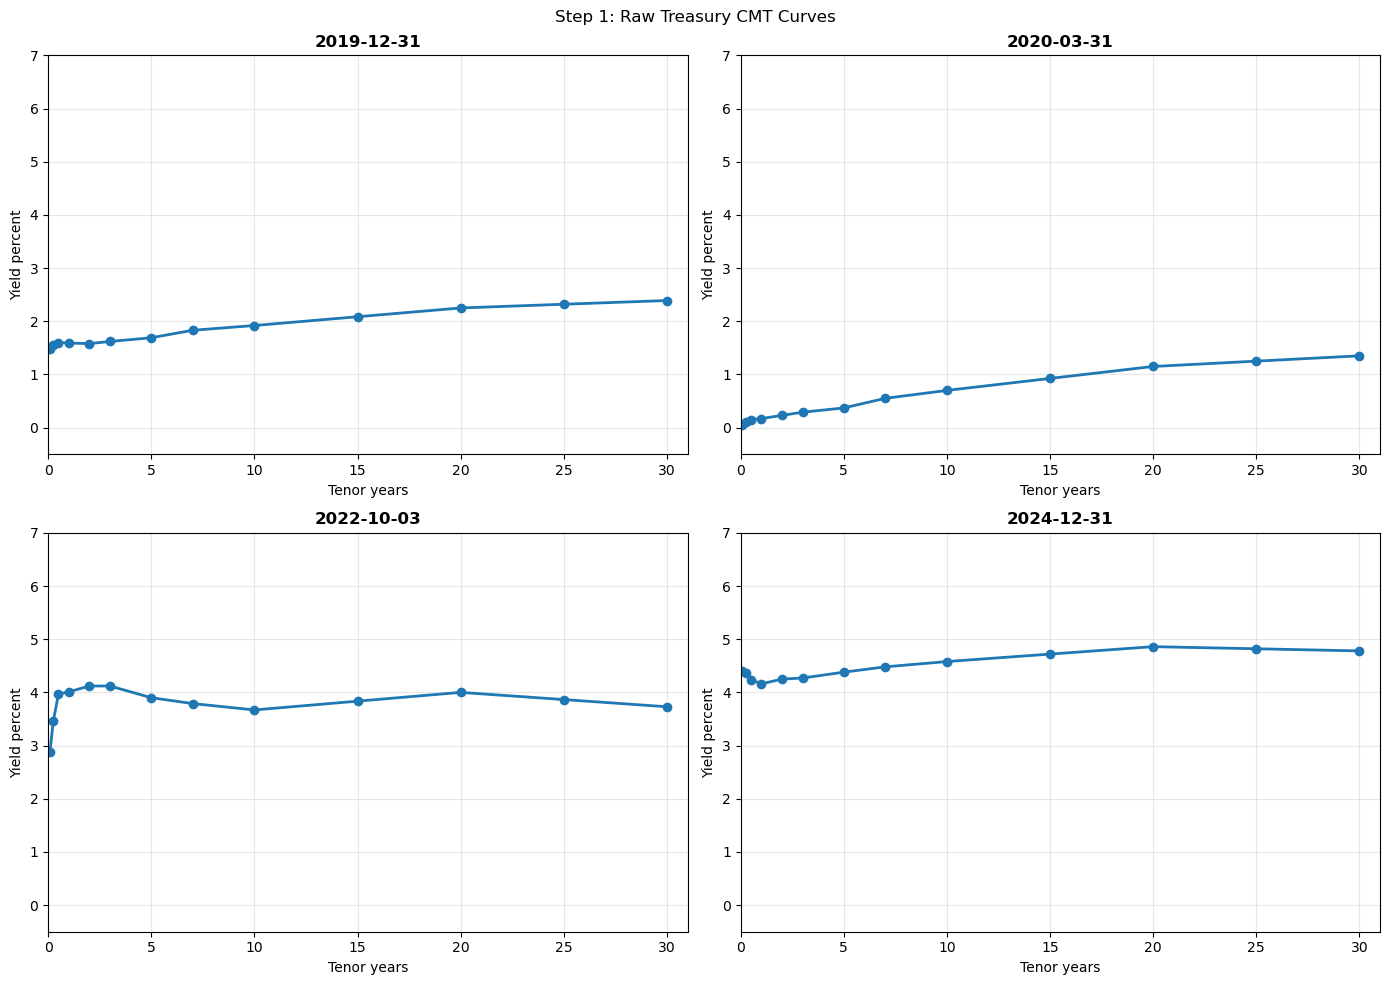


Checkpoint interpretation:
- The raw Treasury curves should be visually readable in a normal 0-7% range.
- If this looks reasonable, move to bootstrapping.


In [3]:
# %% [markdown]
# ## Step 1 — Load data and inspect raw curves
# 
# Goal:
# - confirm sample periods
# - merge Treasury and swap data
# - visually inspect raw Treasury curves before any modeling

# %%
header('STEP 1 — Load Data and Inspect Raw Curves')

frb = pd.read_parquet(RAW_DIR / 'frb_rates.parquet')
swaps = pd.read_parquet(RAW_DIR / 'swap_rates_combined.parquet')
frb['date'] = pd.to_datetime(frb['date'])
swaps['date'] = pd.to_datetime(swaps['date'])

print(f"FRB:   {frb['date'].min().date()} to {frb['date'].max().date()}, {len(frb):,} rows")
print(f"Swaps: {swaps['date'].min().date()} to {swaps['date'].max().date()}, {len(swaps):,} rows")

treasury_cols = [c for c in TREASURY_MAP if c in frb.columns]
swap_cols = [c for c in SWAP_MAP if c in swaps.columns]

tsy = frb[['date'] + treasury_cols].copy()
swp = swaps[['date'] + swap_cols].copy()
if 'dgs10' in tsy.columns:
    tsy = tsy.dropna(subset=['dgs10'])
if 'dswp10' in swp.columns:
    swp = swp.dropna(subset=['dswp10'])

curves = pd.merge(tsy, swp, on='date', how='inner')
curves.to_parquet(OUT_DIR / 'curves_raw.parquet')

print(f"Combined sample: {curves['date'].min().date()} to {curves['date'].max().date()}, {len(curves):,} trading days")
print(f"Saved: {OUT_DIR / 'curves_raw.parquet'}")


def build_treasury_curve(date_str: str) -> Curve:
    date = pd.Timestamp(date_str)
    idx = (curves['date'] - date).abs().argsort().iloc[0]
    row = curves.iloc[idx]
    tenors, rates = [], []
    for col, T in TREASURY_MAP.items():
        if col in row.index:
            v = row.get(col, np.nan)
            if pd.notna(v) and v > 0:
                tenors.append(float(T))
                rates.append(float(v))
    return make_curve(row['date'], tenors, rates)

sample_dates = ['2019-12-31', '2020-03-31', '2022-10-03', '2024-12-31']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, d in zip(axes.flatten(), sample_dates):
    c = build_treasury_curve(d)
    ax.plot(c.input_tenors, c.input_rates, 'o-', linewidth=2)
    ax.set_title(str(c.date.date()), fontweight='bold')
    ax.set_xlabel('Tenor years')
    ax.set_ylabel('Yield percent')
    set_rate_axis(ax)
    ax.grid(True, alpha=0.3)
plt.suptitle('Step 1: Raw Treasury CMT Curves')
plt.tight_layout()
plt.savefig(OUT_DIR / '01_raw_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- The raw Treasury curves should be visually readable in a normal 0-7% range.')
print('- If this looks reasonable, move to bootstrapping.')



STEP 2 — Treasury Bootstrapping
Curve date selected: 2024-12-31

Selected zero curve points:
    tenor  discount_factor  zero_rate
 0.083333         0.996347   4.391953
 0.250000         0.989193   4.346301
 0.500000         0.979240   4.195681
 1.000000         0.960061   4.075799
 2.000000         0.919254   4.209643
 5.000000         0.804732   4.344909
10.000000         0.633764   4.560782
20.000000         0.373287   4.927033
30.000000         0.240981   4.743464

Repricing validation:
    tenor  par_yield         pv error_bps
 0.083333       4.40 100.000000      0.00
 0.250000       4.37 100.000000      0.00
 0.500000       4.24 100.000000      0.00
 1.000000       4.16 100.000000      0.00
 2.000000       4.25  99.996128     -0.39
 3.000000       4.27 100.000786      0.08
 5.000000       4.38  99.985697     -1.43
 7.000000       4.48  99.990120     -0.99
10.000000       4.58  99.988070     -1.19
20.000000       4.86  99.904374     -9.56
30.000000       4.78  99.972405     -2.76

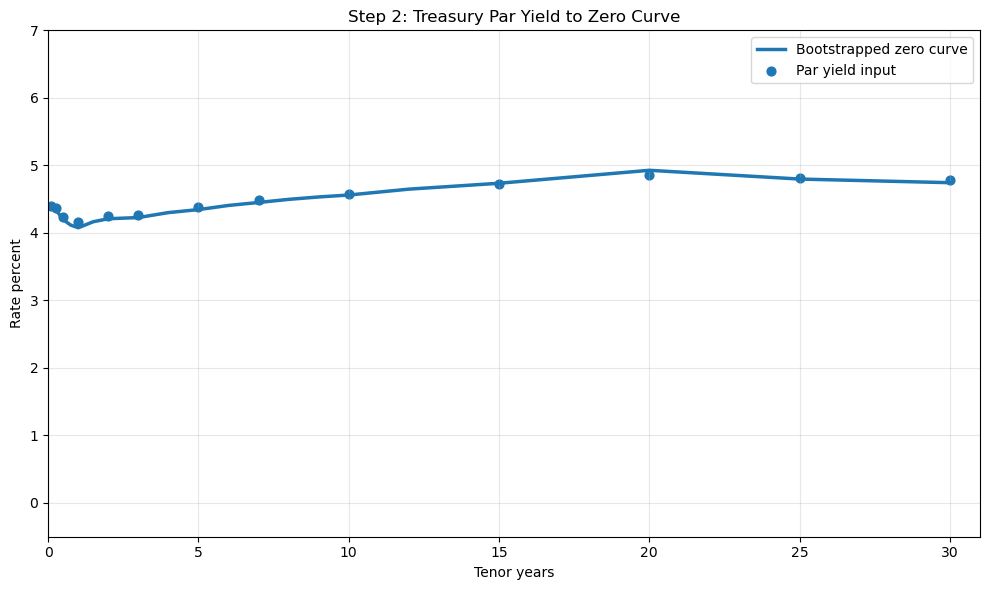


Checkpoint interpretation:
- Discount factors should decline with maturity.
- Repricing should be very tight up to intermediate maturities.
- Next: compare interpolation methods.


In [5]:
# %% [markdown]
# ## Step 2 — Bootstrap par yields into discount factors and zero rates
# 
# Goal:
# - convert par yields to discount factors
# - validate the curve by repricing the original par instruments

# %%
header('STEP 2 — Treasury Bootstrapping')

curve_20241231 = build_treasury_curve('2024-12-31')
curve_df = pd.DataFrame({
    'tenor': curve_20241231.t_grid,
    'discount_factor': curve_20241231.p_grid,
    'zero_rate': curve_20241231.z_grid,
})
curve_df.to_parquet(OUT_DIR / '02_curve_20241231.parquet')

print(f"Curve date selected: {curve_20241231.date.date()}")
print('\nSelected zero curve points:')
print(curve_df[curve_df['tenor'].isin([1/12, 0.25, 0.5, 1, 2, 5, 10, 20, 30])].to_string(index=False))


def validate_repricing(curve: Curve) -> pd.DataFrame:
    rows = []
    for T, par in zip(curve.input_tenors, curve.input_rates):
        if T in [15.0, 25.0]:
            continue
        c = par / 100.0
        if T <= 1.0:
            p_T = interp_df(T, np.array(curve.t_nodes), curve.p_nodes)
            pv = (1.0 + c * T) * p_T * 100.0
        else:
            coupon_dates = np.arange(0.5, T + 1e-8, 0.5)
            pv = 0.0
            for tc in coupon_dates:
                p = interp_df(tc, np.array(curve.t_nodes), curve.p_nodes)
                if abs(tc - T) < 1e-8:
                    pv += (1.0 + c / 2.0) * p * 100.0
                else:
                    pv += (c / 2.0) * p * 100.0
        rows.append({'tenor': T, 'par_yield': par, 'pv': pv, 'error_bps': (pv - 100.0) * 100.0})
    return pd.DataFrame(rows)

repricing = validate_repricing(curve_20241231)
repricing.to_parquet(OUT_DIR / '02_repricing_check.parquet')
print('\nRepricing validation:')
print(repricing.to_string(index=False, formatters={'error_bps': '{:.2f}'.format}))
print(f"Max absolute repricing error: {repricing['error_bps'].abs().max():.2f} bps")

plt.figure(figsize=(10, 6))
plt.plot(curve_20241231.t_grid, curve_20241231.z_grid, linewidth=2.5, label='Bootstrapped zero curve')
plt.scatter(curve_20241231.input_tenors, curve_20241231.input_rates, s=40, label='Par yield input')
plt.title('Step 2: Treasury Par Yield to Zero Curve')
plt.xlabel('Tenor years')
plt.ylabel('Rate percent')
plt.ylim(-0.5, 7.0)
plt.xlim(0, 31)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '02_bootstrapped_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- Discount factors should decline with maturity.')
print('- Repricing should be very tight up to intermediate maturities.')
print('- Next: compare interpolation methods.')



STEP 3 — Interpolation Comparison
Interpolation comparison sample:
    tenor  logdf_zero  pchip_zero  cubicspline_zero  nss_zero  forward_rate
 0.083333    4.391953    4.391953          4.391953  4.393095           NaN
 0.250000    4.346301    4.346301          4.346301  4.340024      4.323475
 0.500000    4.195681    4.195681          4.195681  4.199013      4.045061
 1.000000    4.075799    4.075799          4.075799  4.113743      3.955917
 2.000000    4.209643    4.209643          4.209643  4.143591      4.343486
 5.000000    4.344909    4.344909          4.344909  4.356019      4.521782
10.000000    4.560782    4.560782          4.560782  4.617207      4.818044
20.000000    4.927033    4.927033          4.927033  4.815934      5.503300
30.000000    4.743464    4.743464          4.743464  4.803189      4.473994


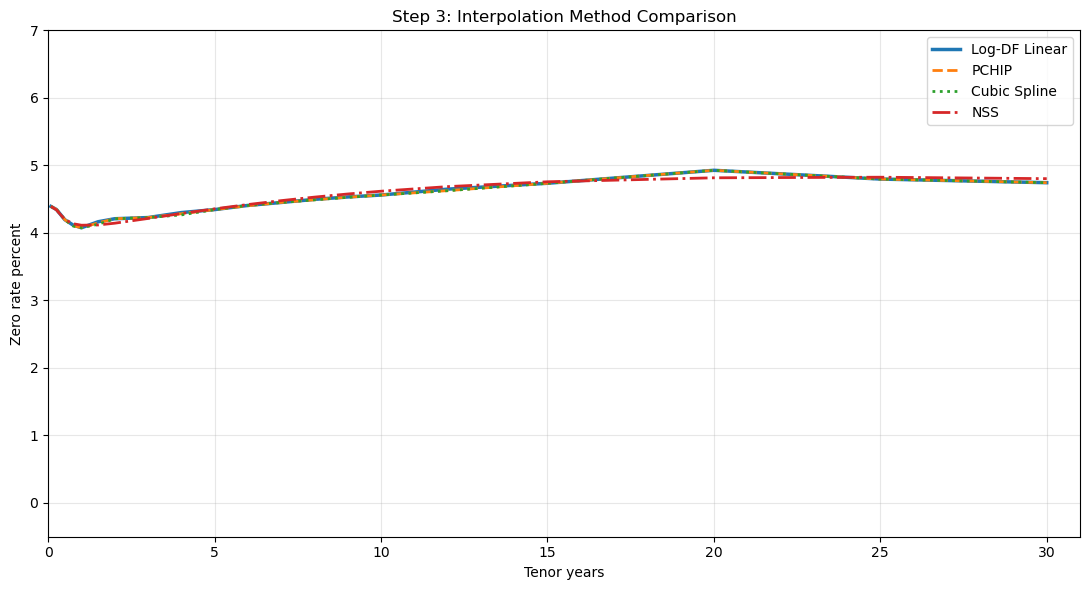


Checkpoint interpretation:
- Log-DF Linear will be used as the stable baseline.
- PCHIP is a smooth shape-preserving alternative.
- Cubic spline may oscillate in stressed or inverted-curve periods.
- NSS is mainly for economic interpretation.


In [7]:
# %% [markdown]
# ## Step 3 — Compare interpolation methods
# 
# Goal:
# - compare Log-DF Linear, PCHIP, Cubic Spline, NSS
# - choose the stable baseline for the project

# %%
header('STEP 3 — Interpolation Comparison')


def nss_yield(T: np.ndarray, params: np.ndarray) -> np.ndarray:
    b0, b1, b2, b3, t1, t2 = params
    T = np.atleast_1d(np.array(T, dtype=np.float64))
    T = np.where(T < 1e-6, 1e-6, T)
    f1 = (1.0 - np.exp(-T / t1)) / (T / t1)
    f2 = f1 - np.exp(-T / t1)
    f3 = (1.0 - np.exp(-T / t2)) / (T / t2) - np.exp(-T / t2)
    return b0 + b1 * f1 + b2 * f2 + b3 * f3


def fit_nss(tenors: np.ndarray, zero_rates: np.ndarray) -> Optional[np.ndarray]:
    if len(tenors) < 4:
        return None
    inits = [
        [zero_rates[-1], zero_rates[0] - zero_rates[-1], -1, -1, 1.5, 8.0],
        [4.0, -1.0, 0.5, 0.5, 2.0, 10.0],
        [zero_rates.mean(), 0.0, 0.0, 0.0, 1.0, 5.0],
    ]
    bounds = [(-5, 20), (-15, 15), (-15, 15), (-15, 15), (0.1, 30), (0.1, 30)]
    best, best_loss = None, np.inf
    for x0 in inits:
        try:
            res = minimize(lambda p: np.sum((nss_yield(tenors, p) - zero_rates) ** 2), x0, method='L-BFGS-B', bounds=bounds)
            if res.fun < best_loss:
                best_loss = float(res.fun)
                best = res.x
        except Exception:
            continue
    return best


t_nodes = np.array(curve_20241231.t_nodes, dtype=np.float64)
p_nodes = np.array(curve_20241231.p_nodes, dtype=np.float64)
z_nodes = np.array([df_to_zero(t, p) for t, p in zip(t_nodes, p_nodes)], dtype=np.float64)

logP_grid = np.interp(T_GRID, t_nodes, np.log(p_nodes))
p_loglin = np.exp(logP_grid)
z_loglin = np.array([df_to_zero(t, p) for t, p in zip(T_GRID, p_loglin)])

p_pchip = np.clip(PchipInterpolator(t_nodes, p_nodes)(T_GRID), 0.001, 1.0)
z_pchip = np.array([df_to_zero(t, p) for t, p in zip(T_GRID, p_pchip)])

z_cubic = CubicSpline(t_nodes, z_nodes, bc_type='not-a-knot')(T_GRID)

real_t = np.array([t for t in curve_20241231.input_tenors if t not in [15.0, 25.0]])
real_z = np.array([df_to_zero(t, interp_df(t, t_nodes, p_nodes)) for t in real_t])
nss_params = fit_nss(real_t, real_z)
z_nss = nss_yield(T_GRID, nss_params) if nss_params is not None else z_loglin.copy()

fwd = np.full(len(T_GRID), np.nan)
for i in range(1, len(T_GRID)):
    fwd[i] = (np.log(p_loglin[i - 1]) - np.log(p_loglin[i])) / (T_GRID[i] - T_GRID[i - 1]) * 100.0

interp_df_out = pd.DataFrame({
    'tenor': T_GRID,
    'logdf_zero': z_loglin,
    'pchip_zero': z_pchip,
    'cubicspline_zero': z_cubic,
    'nss_zero': z_nss,
    'forward_rate': fwd,
})
interp_df_out.to_parquet(OUT_DIR / '03_interpolation_20241231.parquet')

print('Interpolation comparison sample:')
print(interp_df_out[interp_df_out['tenor'].isin([1/12, 0.25, 0.5, 1, 2, 5, 10, 20, 30])].to_string(index=False))

plt.figure(figsize=(11, 6))
plt.plot(T_GRID, z_loglin, linewidth=2.5, label='Log-DF Linear')
plt.plot(T_GRID, z_pchip, '--', linewidth=2, label='PCHIP')
plt.plot(T_GRID, z_cubic, ':', linewidth=2, label='Cubic Spline')
plt.plot(T_GRID, z_nss, '-.', linewidth=2, label='NSS')
plt.title('Step 3: Interpolation Method Comparison')
plt.xlabel('Tenor years')
plt.ylabel('Zero rate percent')
plt.ylim(-0.5, 7.0)
plt.xlim(0, 31)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '03_interpolation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- Log-DF Linear will be used as the stable baseline.')
print('- PCHIP is a smooth shape-preserving alternative.')
print('- Cubic spline may oscillate in stressed or inverted-curve periods.')
print('- NSS is mainly for economic interpretation.')



STEP 4 — DV01, Key Rate Duration, and 2022 Stress P&L
Portfolio DV01 table:
                       label      price  dv01_per100    dv01_total  notional
                 2Y Treasury  99.996128     0.019381  19381.351902       100
                 5Y Treasury  99.985697     0.045416  68123.811033       150
                10Y Treasury  99.988070     0.081168 162335.124698       200
                30Y Treasury  99.972405     0.160940  80469.784769        50
7Y Corporate-like Fixed Bond 104.290522     0.062325  62325.275192       100

Portfolio total DV01 = $392,635 per 1bp

2022 full revaluation P&L:
                       label  yield_change_bps      pnl_M
                 2Y Treasury        357.265361  -7.184272
                 5Y Treasury        255.071588 -19.263420
                10Y Treasury        217.700779 -43.252955
                30Y Treasury        184.008362 -24.440387
7Y Corporate-like Fixed Bond        234.604757 -16.875951
Total 2022 P&L = $-111.02M


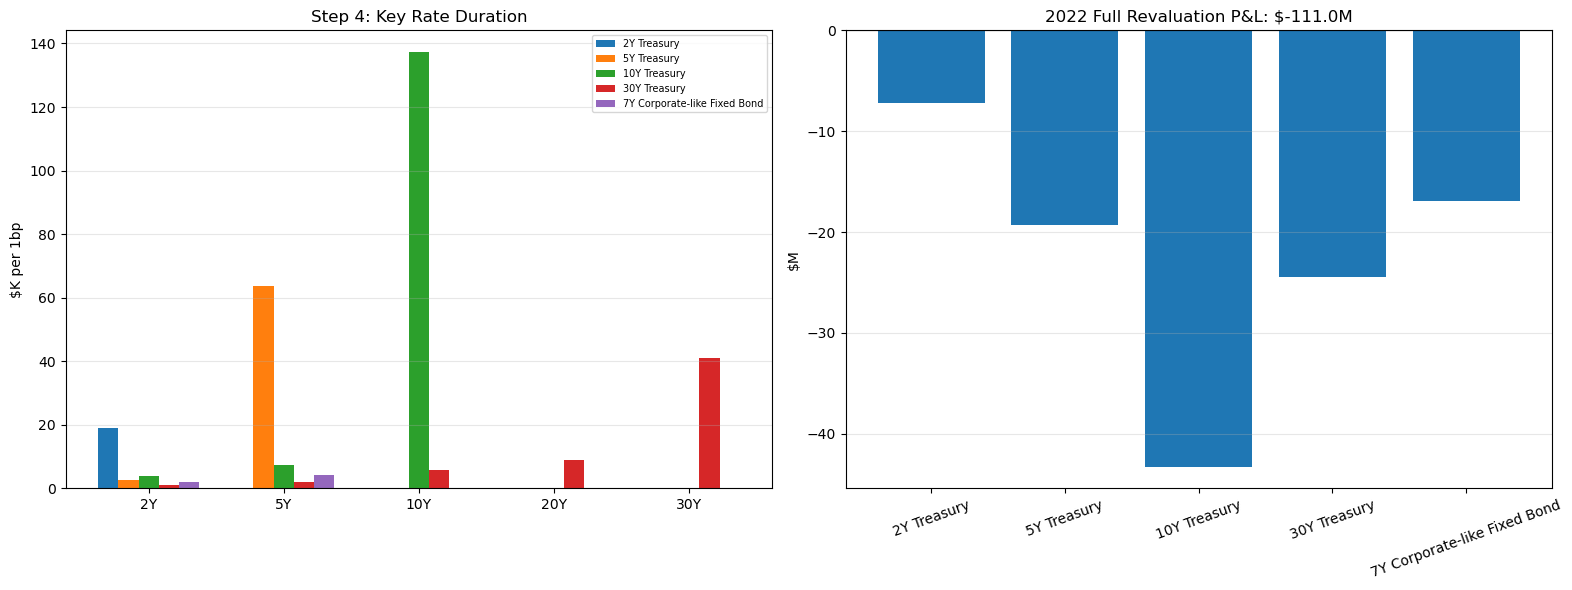


Checkpoint interpretation:
- DV01 converts rate sensitivity into dollars.
- 2022 P&L is static-maturity full revaluation, not yet carry/rolldown attribution.
- Next: compress daily curve changes into PCA factors.


In [9]:
# %% [markdown]
# ## Step 4 — DV01, Key Rate Duration, and 2022 full revaluation P&L
# 
# Goal:
# - translate the curve into portfolio risk
# - measure realized 2022 loss under full revaluation

# %%
header('STEP 4 — DV01, Key Rate Duration, and 2022 Stress P&L')


def price_bond(T_mat: float, coupon_pct: float, t_nodes: List[float], p_nodes: np.ndarray) -> float:
    if T_mat <= 0:
        return 100.0
    c = coupon_pct / 100.0
    coupon_dates = []
    t = T_mat
    while t > 1e-6:
        coupon_dates.append(t)
        t -= 0.5
    coupon_dates = sorted([x for x in coupon_dates if x > 1e-6])
    px = 0.0
    for tc in coupon_dates:
        p = interp_df(tc, np.asarray(t_nodes), np.asarray(p_nodes))
        if abs(tc - T_mat) < 1e-4:
            px += (1.0 + c / 2.0) * p * 100.0
        else:
            px += (c / 2.0) * p * 100.0
    return float(px)


def dv01_bond(T_mat: float, coupon_pct: float, curve: Curve, bump: float = 0.0001) -> float:
    p0 = price_bond(T_mat, coupon_pct, curve.t_nodes, curve.p_nodes)
    bumped = curve.p_nodes * np.exp(-bump * np.asarray(curve.t_nodes))
    p1 = price_bond(T_mat, coupon_pct, curve.t_nodes, bumped)
    return -(p1 - p0)


def key_rate_duration(T_mat: float, coupon_pct: float, curve: Curve, krd_tenors=(2, 5, 10, 20, 30), bump=0.0001) -> Dict[int, float]:
    p0 = price_bond(T_mat, coupon_pct, curve.t_nodes, curve.p_nodes)
    t_arr = np.asarray(curve.t_nodes, dtype=np.float64)
    out = {}
    for krd_t in krd_tenors:
        weights = np.zeros(len(t_arr))
        for i, t in enumerate(t_arr):
            dist = abs(t - krd_t)
            if dist < 2.0:
                weights[i] = max(0.0, 1.0 - dist / 2.0)
        bumped = curve.p_nodes * np.exp(-bump * weights * t_arr)
        bumped = np.clip(bumped, 0.001, 1.0)
        p1 = price_bond(T_mat, coupon_pct, curve.t_nodes, bumped)
        out[int(krd_t)] = -(p1 - p0)
    return out


dv01_rows = []
for T, coupon, notional_m, label in PORTFOLIO:
    px = price_bond(T, coupon, curve_20241231.t_nodes, curve_20241231.p_nodes)
    dv = dv01_bond(T, coupon, curve_20241231)
    krd = key_rate_duration(T, coupon, curve_20241231)
    scale = notional_m * 1_000_000 / 100.0
    row = {
        'label': label,
        'tenor': T,
        'coupon': coupon,
        'notional': notional_m,
        'price': px,
        'dv01_per100': dv,
        'dv01_total': dv * scale,
    }
    for k, v in krd.items():
        row[f'krd_{k}Y'] = v * scale
    dv01_rows.append(row)

dv01_data = pd.DataFrame(dv01_rows)
dv01_data.to_parquet(OUT_DIR / '04_dv01_20241231.parquet')

print('Portfolio DV01 table:')
print(dv01_data[['label', 'price', 'dv01_per100', 'dv01_total', 'notional']].to_string(index=False))
print(f"\nPortfolio total DV01 = ${dv01_data['dv01_total'].sum():,.0f} per 1bp")


def full_revaluation_pnl(start: str, end: str) -> pd.DataFrame:
    c1 = build_treasury_curve(start)
    c2 = build_treasury_curve(end)
    rows = []
    for T, coupon, notional_m, label in PORTFOLIO:
        p0 = price_bond(T, coupon, c1.t_nodes, c1.p_nodes)
        p1 = price_bond(T, coupon, c2.t_nodes, c2.p_nodes)
        z0 = float(np.interp(T, c1.t_grid, c1.z_grid))
        z1 = float(np.interp(T, c2.t_grid, c2.z_grid))
        rows.append({
            'label': label,
            'tenor': T,
            'notional': notional_m,
            'price_start': p0,
            'price_end': p1,
            'pnl_M': (p1 - p0) / 100.0 * notional_m,
            'yield_change_bps': (z1 - z0) * 100.0,
        })
    return pd.DataFrame(rows)

pnl_2022 = full_revaluation_pnl('2022-01-03', '2022-12-30')
pnl_2022.to_parquet(OUT_DIR / '04_pnl_2022_full.parquet')

print('\n2022 full revaluation P&L:')
print(pnl_2022[['label', 'yield_change_bps', 'pnl_M']].to_string(index=False))
print(f"Total 2022 P&L = ${pnl_2022['pnl_M'].sum():.2f}M")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
krd_cols = ['krd_2Y', 'krd_5Y', 'krd_10Y', 'krd_20Y', 'krd_30Y']
x = np.arange(len(krd_cols))
width = 0.15
for i, (_, row) in enumerate(dv01_data.iterrows()):
    axes[0].bar(x + i * width, [row[c] / 1000.0 for c in krd_cols], width, label=row['label'])
axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(['2Y', '5Y', '10Y', '20Y', '30Y'])
axes[0].set_title('Step 4: Key Rate Duration')
axes[0].set_ylabel('$K per 1bp')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(pnl_2022['label'], pnl_2022['pnl_M'])
axes[1].axhline(0, color='black')
axes[1].set_title(f"2022 Full Revaluation P&L: ${pnl_2022['pnl_M'].sum():.1f}M")
axes[1].set_ylabel('$M')
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / '04_dv01_stress.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- DV01 converts rate sensitivity into dollars.')
print('- 2022 P&L is static-maturity full revaluation, not yet carry/rolldown attribution.')
print('- Next: compress daily curve changes into PCA factors.')



STEP 5 — PCA Level/Slope/Curvature Decomposition
PCA variance explained:
  PC1:  76.50% | cumulative:  76.50%
  PC2:  13.25% | cumulative:  89.75%
  PC3:   5.84% | cumulative:  95.59%
  PC4:   1.77% | cumulative:  97.36%
  PC5:   0.94% | cumulative:  98.30%

3-factor reconstruction quality:
   0.25Y | std= 4.61 bps | RMSE= 1.25 bps | R2=0.9267
   0.50Y | std= 3.84 bps | RMSE= 1.42 bps | R2=0.8635
   1.00Y | std= 4.22 bps | RMSE= 1.56 bps | R2=0.8624
   2.00Y | std= 5.50 bps | RMSE= 1.08 bps | R2=0.9611
   3.00Y | std= 5.84 bps | RMSE= 0.95 bps | R2=0.9738
   5.00Y | std= 6.13 bps | RMSE= 1.02 bps | R2=0.9724
   7.00Y | std= 6.15 bps | RMSE= 0.99 bps | R2=0.9742
  10.00Y | std= 5.84 bps | RMSE= 0.81 bps | R2=0.9809
  20.00Y | std= 5.54 bps | RMSE= 0.83 bps | R2=0.9778
  30.00Y | std= 5.35 bps | RMSE= 1.11 bps | R2=0.9572


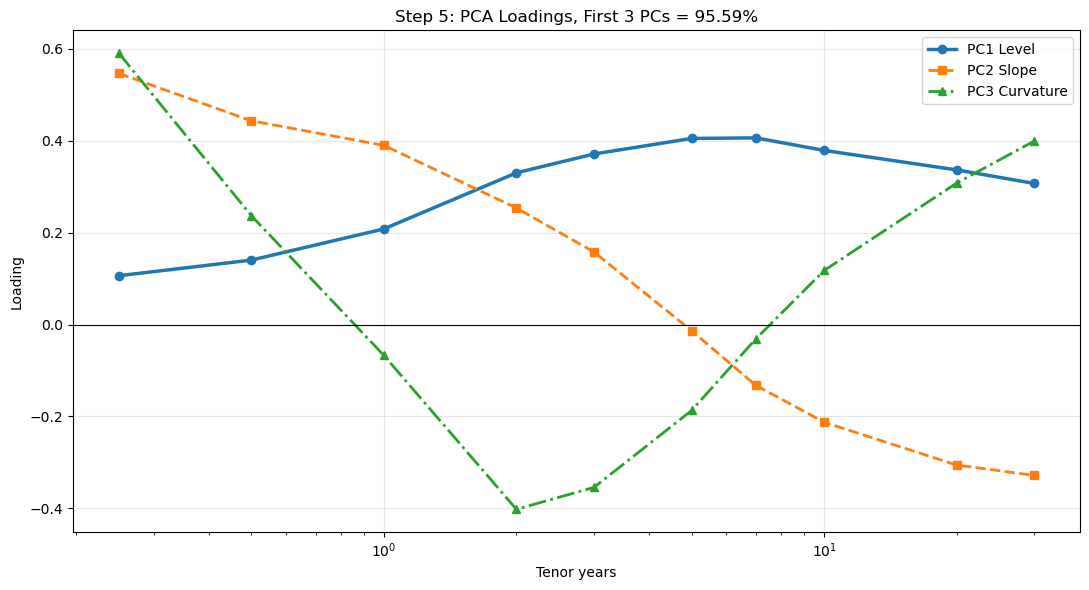


Checkpoint interpretation:
- PC1 should look like a broad level shift.
- PC2 should look like a slope factor.
- PC3 should look like a curvature factor.
- Next: separate discounting and projection in a multi-curve extension.


In [11]:
# %% [markdown]
# ## Step 5 — PCA on daily yield-curve changes
# 
# Goal:
# - show that level, slope, curvature summarize most daily curve variation

# %%
header('STEP 5 — PCA Level/Slope/Curvature Decomposition')

pca_cols = [c for c, _ in PCA_TENOR_MAP]
pca_tenors = np.array([t for _, t in PCA_TENOR_MAP], dtype=np.float64)

y = curves[['date'] + pca_cols].dropna().sort_values('date').reset_index(drop=True)
y_mat = y[pca_cols].to_numpy(dtype=np.float64)
dates = y['date'].values[1:]
dy = np.diff(y_mat, axis=0) * 100.0
mask = np.all(np.abs(dy) < 100.0, axis=1)
dy_clean = dy[mask].astype(np.float64)
dates_clean = dates[mask]

pca = PCA(n_components=5)
factors = pca.fit_transform(dy_clean).astype(np.float64)
loadings = pca.components_.astype(np.float64)
explained = pca.explained_variance_ratio_

reconstruction = pca.mean_ + factors[:, :3] @ loadings[:3, :]
residual = dy_clean - reconstruction
rmse_3pc = np.sqrt(np.mean(residual ** 2, axis=0))
std_dy = np.std(dy_clean, axis=0)

pca_model = PCAModel(
    tenors=pca_tenors,
    loadings=loadings,
    factors=factors,
    explained_variance=explained,
    mean=pca.mean_,
    dates=dates_clean,
    rmse_3pc=rmse_3pc,
    std_dy=std_dy,
)

pd.DataFrame({
    'tenor': pca_model.tenors,
    'pc1_level': pca_model.loadings[0],
    'pc2_slope': pca_model.loadings[1],
    'pc3_curvature': pca_model.loadings[2],
    'rmse_3pc': pca_model.rmse_3pc,
    'std_dy': pca_model.std_dy,
}).to_parquet(OUT_DIR / '05_factor_loadings.parquet')

print('PCA variance explained:')
cum = 0.0
for i, v in enumerate(explained[:5]):
    cum += v
    print(f"  PC{i+1}: {v*100:6.2f}% | cumulative: {cum*100:6.2f}%")

r2 = 1.0 - (rmse_3pc / std_dy) ** 2
print('\n3-factor reconstruction quality:')
for t, s, r, r2v in zip(pca_tenors, std_dy, rmse_3pc, r2):
    print(f"  {t:>5.2f}Y | std={s:5.2f} bps | RMSE={r:5.2f} bps | R2={r2v:6.4f}")

plt.figure(figsize=(11, 6))
plt.plot(pca_tenors, loadings[0], 'o-', linewidth=2.5, label='PC1 Level')
plt.plot(pca_tenors, loadings[1], 's--', linewidth=2, label='PC2 Slope')
plt.plot(pca_tenors, loadings[2], '^-.', linewidth=2, label='PC3 Curvature')
plt.xscale('log')
plt.axhline(0, color='black', linewidth=0.8)
plt.title(f"Step 5: PCA Loadings, First 3 PCs = {explained[:3].sum()*100:.2f}%")
plt.xlabel('Tenor years')
plt.ylabel('Loading')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / '05_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- PC1 should look like a broad level shift.')
print('- PC2 should look like a slope factor.')
print('- PC3 should look like a curvature factor.')
print('- Next: separate discounting and projection in a multi-curve extension.')



STEP 6 — Multi-Curve Extension: Discounting vs Projection
OIS-like discount curve date: 2024-12-31
Projection curve date: 2024-12-31

IRS repricing results:
 tenor  market_swap_rate  model_par_rate error_bps
   2.0            4.3462        4.373370      2.72
   5.0            4.3035        4.314368      1.09
  10.0            4.3375        4.342934      0.54
  30.0            4.1988        4.200611      0.18
Max absolute repricing error: 2.72 bps


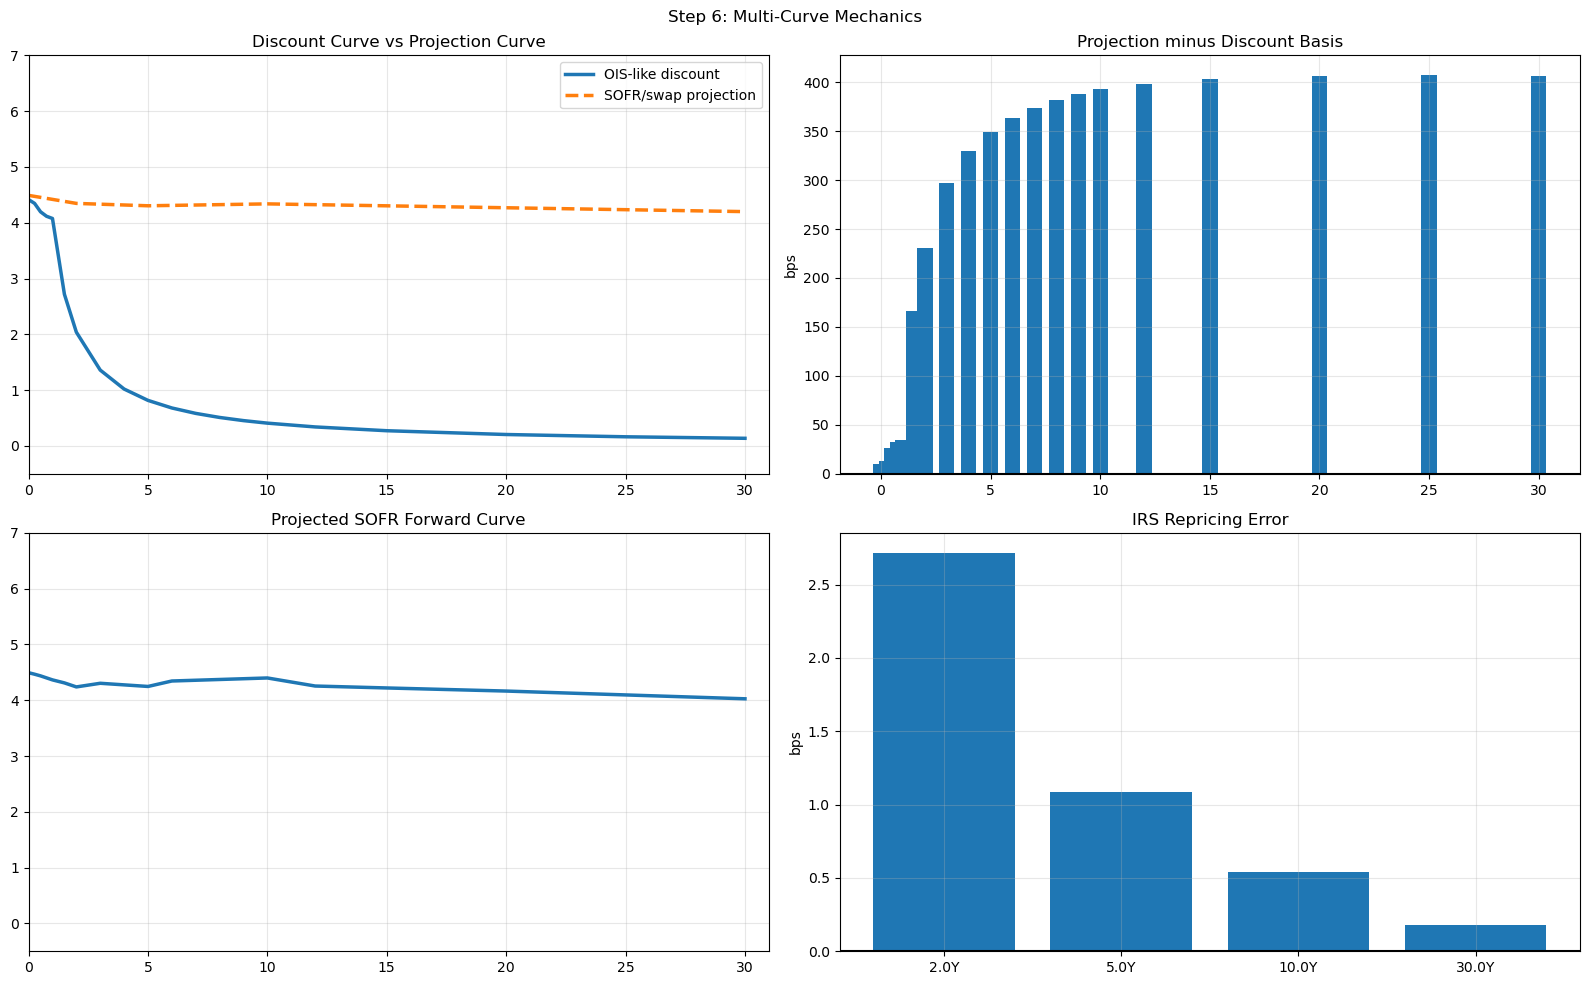


Checkpoint interpretation:
- This step separates discounting from floating-rate projection.
- Repricing error is evaluated under proxy multi-curve construction, not full market strips.
- Next: explain 2022 P&L by carry and PCA factors.


In [13]:
# %% [markdown]
# ## Step 6 — Multi-curve extension
# 
# Goal:
# - separate OIS-like discounting from SOFR/swap-implied projection
# - reprice IRS par swap rates using different discounting and projection curves

# %%
header('STEP 6 — Multi-Curve Extension: Discounting vs Projection')


def build_ois_like_curve(date_str: str) -> Curve:
    date = pd.Timestamp(date_str)
    idx = (frb['date'] - date).abs().argsort().iloc[0]
    row = frb.iloc[idx]
    tenors, rates = [], []
    short = get_first_available(row, ['sofr', 'SOFR', 'effr', 'EFFR'])
    if pd.notna(short):
        tenors.append(1 / 365)
        rates.append(short)
    for col in ['dgs1mo', 'dgs3mo', 'dgs6mo', 'dgs1']:
        if col in row.index:
            v = row.get(col, np.nan)
            if pd.notna(v) and v > 0:
                tenors.append(float(TREASURY_MAP[col]))
                rates.append(float(v))
    return make_curve(row['date'], tenors, rates)


def build_projection_curve(date_str: str) -> Dict[str, np.ndarray]:
    date = pd.Timestamp(date_str)
    fidx = (frb['date'] - date).abs().argsort().iloc[0]
    sidx = (swaps['date'] - date).abs().argsort().iloc[0]
    frow = frb.iloc[fidx]
    srow = swaps.iloc[sidx]
    tenors, rates = [], []
    short = get_first_available(frow, ['sofr', 'SOFR', 'effr', 'EFFR'])
    if pd.notna(short):
        tenors.append(1 / 365)
        rates.append(short)
    for col, T in SWAP_MAP.items():
        if col in srow.index:
            v = srow.get(col, np.nan)
            if pd.notna(v) and v > 0:
                tenors.append(float(T))
                rates.append(float(v))
    pairs = sorted(zip(tenors, rates))
    tenors = np.array([p[0] for p in pairs], dtype=np.float64)
    rates = np.array([p[1] for p in pairs], dtype=np.float64)
    pricing_grid = np.array([1/365, 1/12, 0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20, 25, 30], dtype=np.float64)
    z_grid = np.interp(pricing_grid, tenors, rates)
    p_grid = np.exp(-z_grid / 100.0 * pricing_grid)
    fwd = np.full(len(pricing_grid), np.nan)
    for i in range(1, len(pricing_grid)):
        fwd[i] = (np.log(p_grid[i - 1]) - np.log(p_grid[i])) / (pricing_grid[i] - pricing_grid[i - 1]) * 100.0
    return {
        'date': swaps.iloc[sidx]['date'],
        't_grid': pricing_grid,
        'z_grid': z_grid,
        'p_grid': p_grid,
        'forward_grid': fwd,
    }


def fixed_leg_annuity(T: float, discount_curve: Curve) -> float:
    pay_dates = np.arange(1.0, T + 1e-8, 1.0)
    ann = 0.0
    prev = 0.0
    for d in pay_dates:
        tau = d - prev
        df = interp_df(d, discount_curve.t_grid, discount_curve.p_grid)
        ann += tau * df
        prev = d
    return ann


def projection_forward(T1: float, T2: float, projection_curve: Dict[str, np.ndarray]) -> float:
    p1 = interp_df(max(T1, 1e-8), projection_curve['t_grid'], projection_curve['p_grid'])
    p2 = interp_df(T2, projection_curve['t_grid'], projection_curve['p_grid'])
    return (np.log(p1) - np.log(p2)) / (T2 - T1)


def floating_leg_pv(T: float, discount_curve: Curve, projection_curve: Dict[str, np.ndarray], notional: float = 100.0) -> float:
    pay_dates = np.arange(0.25, T + 1e-8, 0.25)
    prev = 0.0
    pv = 0.0
    for d in pay_dates:
        tau = d - prev
        fwd = projection_forward(prev + 1e-8, d, projection_curve)
        df = interp_df(d, discount_curve.t_grid, discount_curve.p_grid)
        pv += notional * fwd * tau * df
        prev = d
    return pv


def par_swap_rate_multicurve(T: float, discount_curve: Curve, projection_curve: Dict[str, np.ndarray]) -> float:
    flt_pv = floating_leg_pv(T, discount_curve, projection_curve, 100.0)
    ann = fixed_leg_annuity(T, discount_curve)
    return flt_pv / (100.0 * ann) * 100.0


ois_curve = build_ois_like_curve('2024-12-31')
projection_curve = build_projection_curve('2024-12-31')

rows = []
row = swaps.iloc[(swaps['date'] - pd.Timestamp('2024-12-31')).abs().argsort().iloc[0]]
for col, T in SWAP_MAP.items():
    if col in row.index:
        market = row.get(col, np.nan)
        if pd.notna(market) and market > 0:
            model = par_swap_rate_multicurve(float(T), ois_curve, projection_curve)
            rows.append({'tenor': float(T), 'market_swap_rate': float(market), 'model_par_rate': float(model), 'error_bps': (model - market) * 100.0})

swap_repricing = pd.DataFrame(rows)
swap_repricing.to_parquet(OUT_DIR / '06_swap_repricing_20241231.parquet')

multi_curve_out = pd.DataFrame({
    'tenor': projection_curve['t_grid'],
    'ois_discount_zero': np.interp(projection_curve['t_grid'], ois_curve.t_grid, ois_curve.z_grid),
    'sofr_projection_zero': projection_curve['z_grid'],
    'sofr_projection_forward': projection_curve['forward_grid'],
    'projection_discount_basis_bps': (projection_curve['z_grid'] - np.interp(projection_curve['t_grid'], ois_curve.t_grid, ois_curve.z_grid)) * 100.0,
})
multi_curve_out.to_parquet(OUT_DIR / '06_multicurve_20241231.parquet')

print(f"OIS-like discount curve date: {ois_curve.date.date()}")
print(f"Projection curve date: {pd.Timestamp(projection_curve['date']).date()}")
print('\nIRS repricing results:')
print(swap_repricing.to_string(index=False, formatters={'error_bps': '{:.2f}'.format}))
print(f"Max absolute repricing error: {swap_repricing['error_bps'].abs().max():.2f} bps")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(ois_curve.t_grid, ois_curve.z_grid, linewidth=2.5, label='OIS-like discount')
axes[0, 0].plot(projection_curve['t_grid'], projection_curve['z_grid'], '--', linewidth=2.5, label='SOFR/swap projection')
axes[0, 0].set_title('Discount Curve vs Projection Curve')
set_rate_axis(axes[0, 0])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

basis = np.interp(projection_curve['t_grid'], ois_curve.t_grid, ois_curve.z_grid)
axes[0, 1].bar(projection_curve['t_grid'], (projection_curve['z_grid'] - basis) * 100.0, width=0.7)
axes[0, 1].axhline(0, color='black')
axes[0, 1].set_title('Projection minus Discount Basis')
axes[0, 1].set_ylabel('bps')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(projection_curve['t_grid'], projection_curve['forward_grid'], linewidth=2.5)
axes[1, 0].set_title('Projected SOFR Forward Curve')
set_rate_axis(axes[1, 0])
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].bar(swap_repricing['tenor'].astype(str) + 'Y', swap_repricing['error_bps'])
axes[1, 1].axhline(0, color='black')
axes[1, 1].set_title('IRS Repricing Error')
axes[1, 1].set_ylabel('bps')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Step 6: Multi-Curve Mechanics')
plt.tight_layout()
plt.savefig(OUT_DIR / '06_multicurve.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- This step separates discounting from floating-rate projection.')
print('- Repricing error is evaluated under proxy multi-curve construction, not full market strips.')
print('- Next: explain 2022 P&L by carry and PCA factors.')



STEP 7 — Factor-Based P&L Attribution
Full-year 2022 P&L attribution:
                       label  pnl_total  pnl_carry    pnl_PC1   pnl_PC2   pnl_PC3  pnl_lin_res  pnl_nonlinear
                 2Y Treasury  -1.021519   3.269793  -1.824302 -2.152641  0.137522    -0.535797       0.083907
                 5Y Treasury -10.514033   6.243865 -20.451954 -2.052624  2.951029     1.889018       0.906633
                10Y Treasury -31.013382   8.899937 -61.840228 17.032077 -1.672995     2.741806       3.826021
                30Y Treasury -21.139430   2.760530 -28.454985 16.544771 -6.345869    -2.356653      -3.287223
7Y Corporate-like Fixed Bond -10.193547   4.858957 -21.688965  2.142123  1.359908     2.074157       1.060272

Attribution totals:
pnl_carry         26.033082
pnl_PC1         -134.260434
pnl_PC2           31.513706
pnl_PC3           -3.570405
pnl_lin_res        3.812532
pnl_nonlinear      2.589610

Component sum = $-73.8819M
Total attribution P&L = $-73.8819M
Difference = $0.0

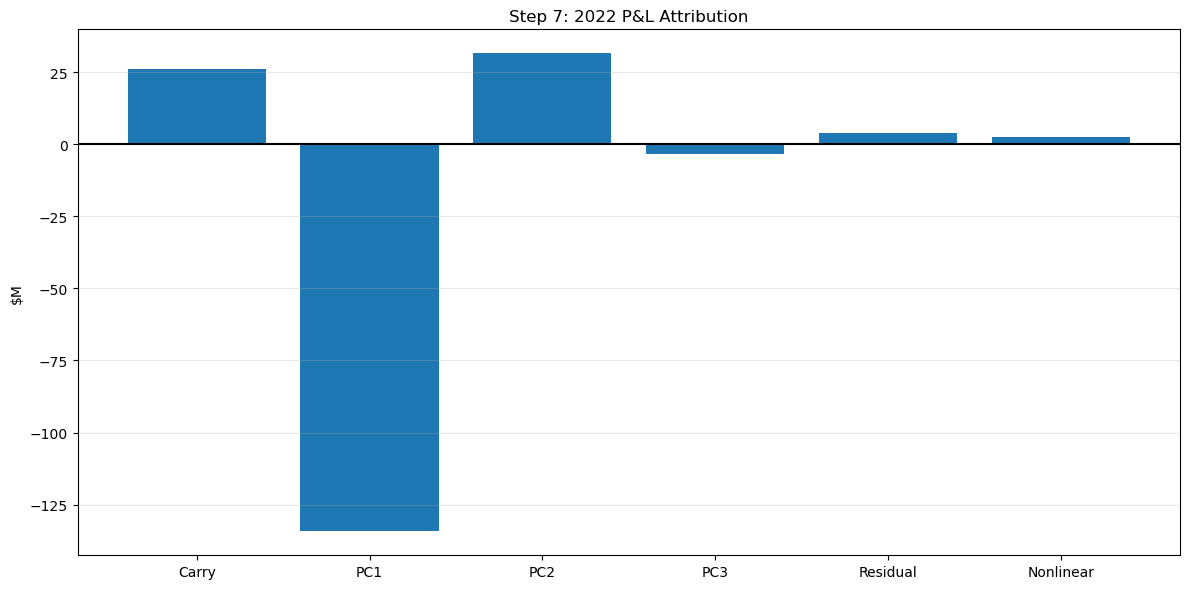


Checkpoint interpretation:
- This is holding-period attribution, not the same as Step 4 static-maturity full revaluation.
- Carry includes coupon accrual and rolldown.
- PC1, PC2, PC3 explain first-order factor contributions.
- Nonlinear term captures convexity and higher-order effects.


In [15]:
# %% [markdown]
# ## Step 7 — Factor-based P&L attribution
# 
# Goal:
# - decompose holding-period P&L into carry, level, slope, curvature, residual, nonlinear terms

# %%
header('STEP 7 — Factor-Based P&L Attribution')


def krd_at_pca_tenors(T_mat: float, coupon_pct: float, curve: Curve, pca_tenors: np.ndarray, bump: float = 0.0001) -> np.ndarray:
    base = price_bond(T_mat, coupon_pct, curve.t_nodes, curve.p_nodes)
    t_arr = np.asarray(curve.t_nodes, dtype=np.float64)
    out = []
    n = len(pca_tenors)
    for i, t_krd in enumerate(pca_tenors):
        if i == 0:
            half_w = (pca_tenors[1] - t_krd) / 2.0
        elif i == n - 1:
            half_w = (t_krd - pca_tenors[-2]) / 2.0
        else:
            half_w = min(pca_tenors[i + 1] - t_krd, t_krd - pca_tenors[i - 1]) / 2.0
        half_w = max(float(half_w), 0.1)
        weights = np.zeros(len(t_arr))
        for j, t in enumerate(t_arr):
            dist = abs(t - t_krd)
            if dist < half_w:
                weights[j] = max(0.0, 1.0 - dist / half_w)
        bumped = curve.p_nodes * np.exp(-bump * weights * t_arr)
        bumped = np.clip(bumped, 0.001, 1.0)
        p1 = price_bond(T_mat, coupon_pct, curve.t_nodes, bumped)
        out.append(-(p1 - base))
    return np.array(out, dtype=np.float64)


def attribute_bond_pnl(bond: Tuple[float, float, float, str], start: str, end: str) -> Dict[str, float]:
    T, coupon, notional_m, label = bond
    c1 = build_treasury_curve(start)
    c2 = build_treasury_curve(end)
    dt = (c2.date - c1.date).days / 365.0
    T_roll = max(T - dt, 1e-6)

    p1 = price_bond(T, coupon, c1.t_nodes, c1.p_nodes)
    p2 = price_bond(T_roll, coupon, c2.t_nodes, c2.p_nodes)
    p_roll = price_bond(T_roll, coupon, c1.t_nodes, c1.p_nodes)

    coupon_income = coupon * dt
    rolldown = p_roll - p1
    carry = coupon_income + rolldown
    yield_pnl = p2 - p_roll
    total = carry + yield_pnl

    y1 = np.interp(pca_model.tenors, c1.t_grid, c1.z_grid)
    y2 = np.interp(pca_model.tenors, c2.t_grid, c2.z_grid)
    dy = y2 - y1

    load = pca_model.loadings[:3]
    dpc = np.array([float(np.dot(dy, load[i])) for i in range(3)])
    dy_pc = np.array([dpc[i] * load[i] for i in range(3)])
    dy_res = dy - dy_pc.sum(axis=0)

    krd = krd_at_pca_tenors(T_roll, coupon, c1, pca_model.tenors)
    pc_pnl = np.array([-float(np.sum(krd * dy_pc[i] * 100.0)) for i in range(3)])
    lin_res = -float(np.sum(krd * dy_res * 100.0))
    linear = float(pc_pnl.sum() + lin_res)
    nonlinear = yield_pnl - linear

    scale = notional_m / 100.0
    return {
        'label': label,
        'notional': notional_m,
        'pnl_total': total * scale,
        'pnl_carry': carry * scale,
        'pnl_coupon': coupon_income * scale,
        'pnl_rolldown': rolldown * scale,
        'pnl_yield': yield_pnl * scale,
        'pnl_PC1': pc_pnl[0] * scale,
        'pnl_PC2': pc_pnl[1] * scale,
        'pnl_PC3': pc_pnl[2] * scale,
        'pnl_lin_res': lin_res * scale,
        'pnl_nonlinear': nonlinear * scale,
    }

pnl_attribution = pd.DataFrame([attribute_bond_pnl(b, '2022-01-03', '2022-12-30') for b in PORTFOLIO])
pnl_attribution.to_parquet(OUT_DIR / '07_pnl_attribution_2022.parquet')

print('Full-year 2022 P&L attribution:')
print(pnl_attribution[['label', 'pnl_total', 'pnl_carry', 'pnl_PC1', 'pnl_PC2', 'pnl_PC3', 'pnl_lin_res', 'pnl_nonlinear']].to_string(index=False))

component_cols = ['pnl_carry', 'pnl_PC1', 'pnl_PC2', 'pnl_PC3', 'pnl_lin_res', 'pnl_nonlinear']
component_totals = pnl_attribution[component_cols].sum()
component_sum = component_totals.sum()
total_attr = pnl_attribution['pnl_total'].sum()

print('\nAttribution totals:')
print(component_totals.to_string())
print(f"\nComponent sum = ${component_sum:.4f}M")
print(f"Total attribution P&L = ${total_attr:.4f}M")
print(f"Difference = ${component_sum - total_attr:.8f}M")

cats = ['Carry', 'PC1', 'PC2', 'PC3', 'Residual', 'Nonlinear']
vals = [
    component_totals['pnl_carry'],
    component_totals['pnl_PC1'],
    component_totals['pnl_PC2'],
    component_totals['pnl_PC3'],
    component_totals['pnl_lin_res'],
    component_totals['pnl_nonlinear'],
]
plt.figure(figsize=(12, 6))
plt.bar(cats, vals)
plt.axhline(0, color='black')
plt.title('Step 7: 2022 P&L Attribution')
plt.ylabel('$M')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(OUT_DIR / '07_pnl_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCheckpoint interpretation:')
print('- This is holding-period attribution, not the same as Step 4 static-maturity full revaluation.')
print('- Carry includes coupon accrual and rolldown.')
print('- PC1, PC2, PC3 explain first-order factor contributions.')
print('- Nonlinear term captures convexity and higher-order effects.')



STEP 8 — Final Summary and README


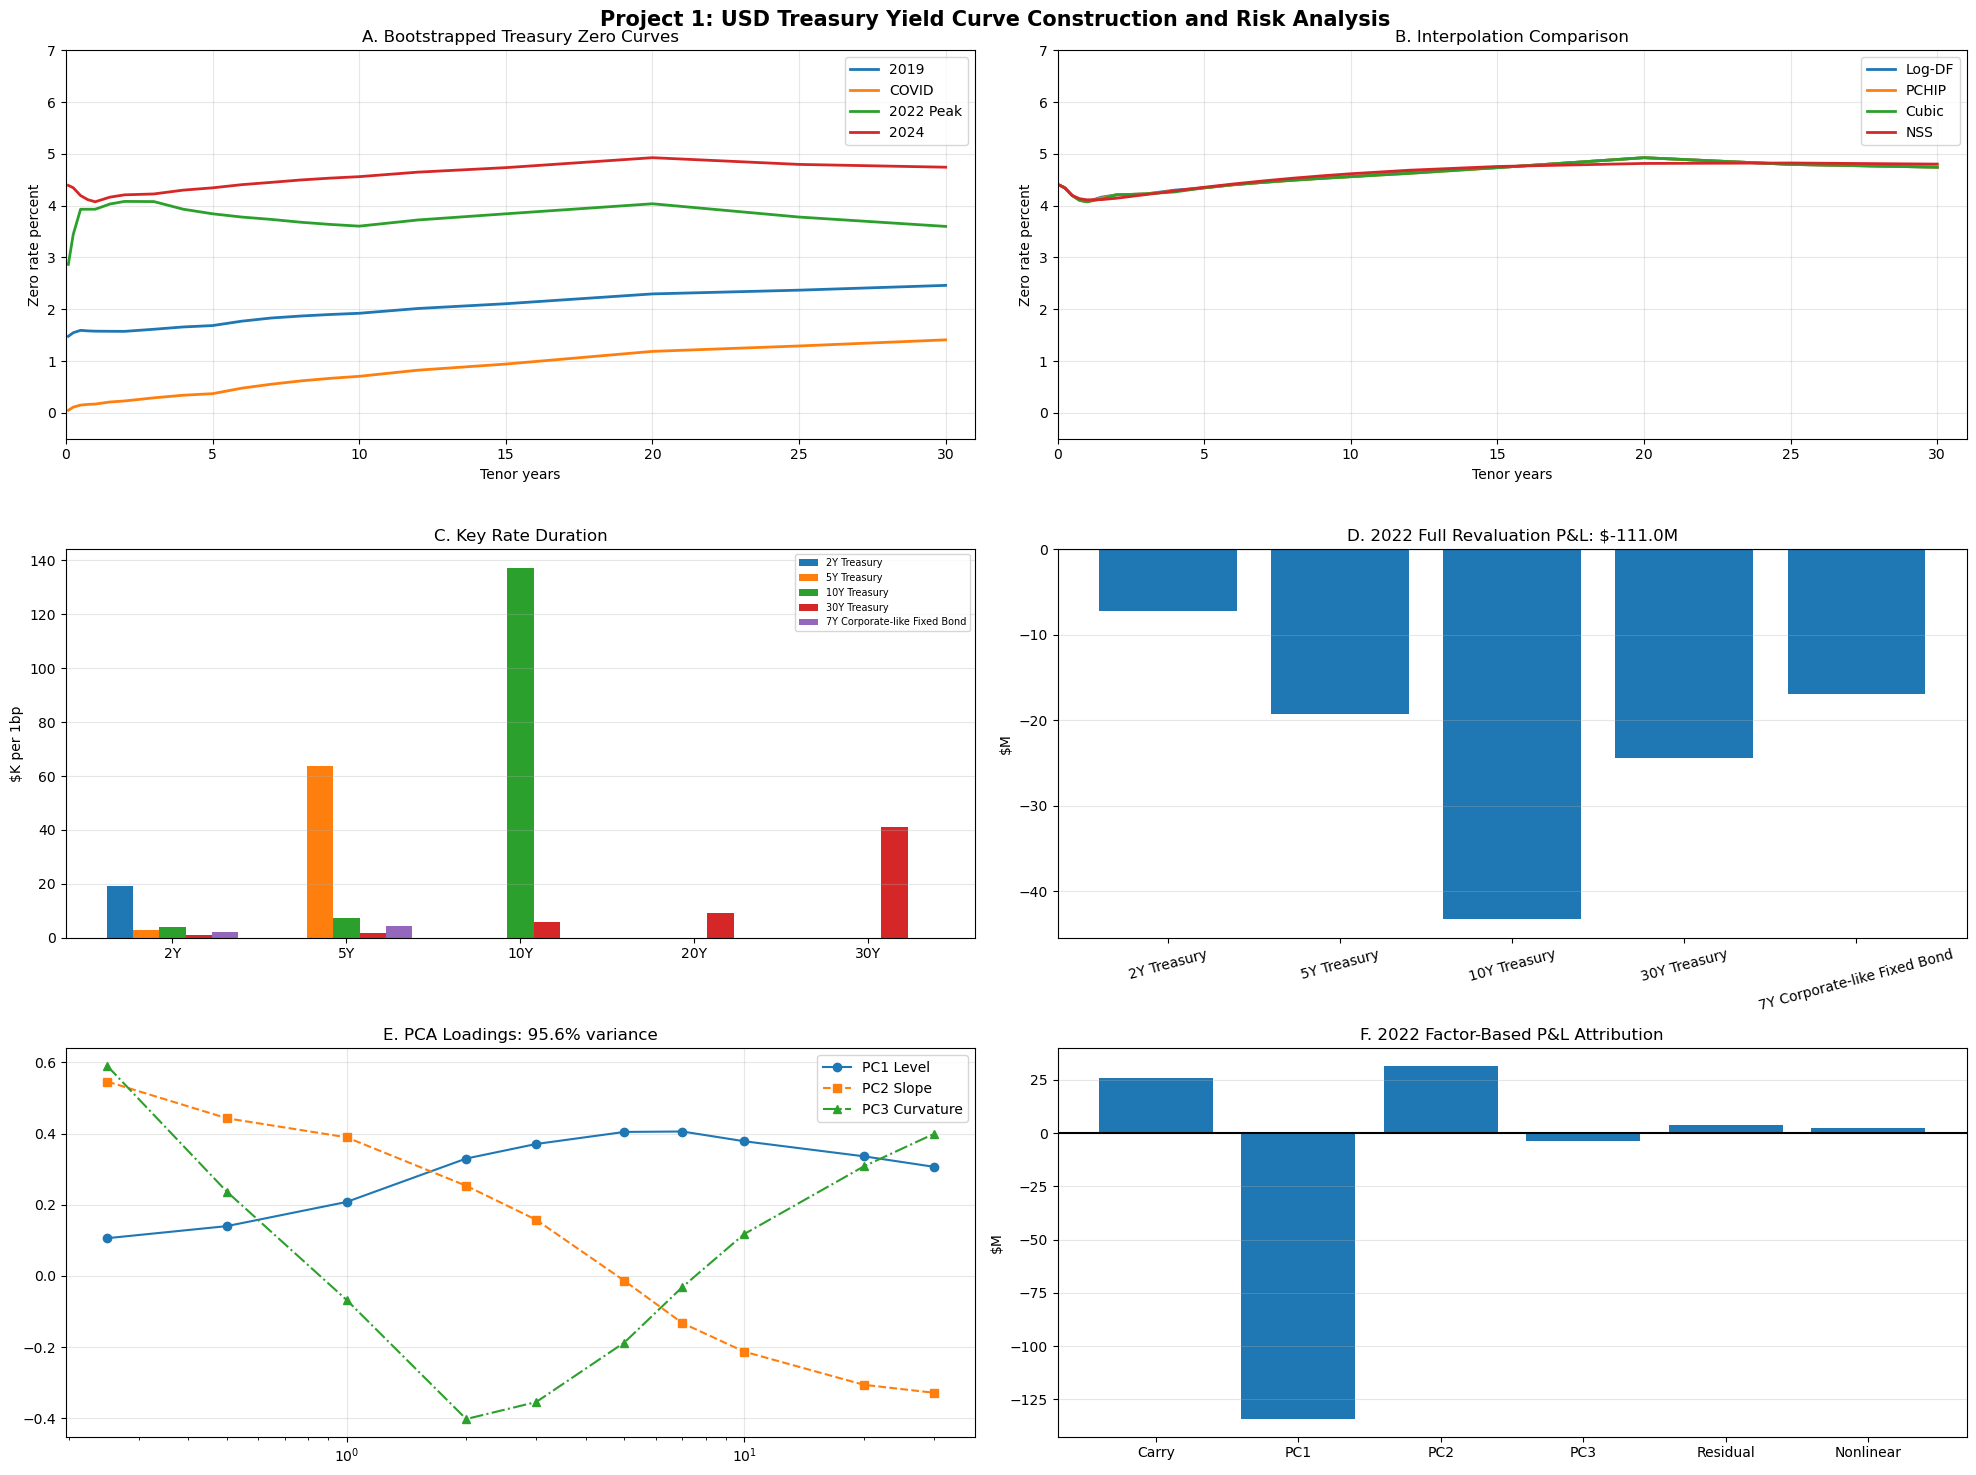

In [17]:
# %% [markdown]
# ## Step 8 — Final summary figure and README
# 
# Goal:
# - collect the project outputs into one summary artifact
# - produce a README-ready project description

# %%
header('STEP 8 — Final Summary and README')

fig, axes = plt.subplots(3, 2, figsize=(20, 15))

for d, label in zip(['2019-12-31', '2020-03-31', '2022-10-03', '2024-12-31'], ['2019', 'COVID', '2022 Peak', '2024']):
    c = build_treasury_curve(d)
    axes[0, 0].plot(c.t_grid, c.z_grid, linewidth=2, label=label)
axes[0, 0].set_title('A. Bootstrapped Treasury Zero Curves')
axes[0, 0].set_xlabel('Tenor years')
axes[0, 0].set_ylabel('Zero rate percent')
set_rate_axis(axes[0, 0])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

for col, name in [('logdf_zero', 'Log-DF'), ('pchip_zero', 'PCHIP'), ('cubicspline_zero', 'Cubic'), ('nss_zero', 'NSS')]:
    axes[0, 1].plot(interp_df_out['tenor'], interp_df_out[col], linewidth=2, label=name)
axes[0, 1].set_title('B. Interpolation Comparison')
axes[0, 1].set_xlabel('Tenor years')
axes[0, 1].set_ylabel('Zero rate percent')
set_rate_axis(axes[0, 1])
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

krd_cols = ['krd_2Y', 'krd_5Y', 'krd_10Y', 'krd_20Y', 'krd_30Y']
x = np.arange(len(krd_cols))
width = 0.15
for i, (_, row) in enumerate(dv01_data.iterrows()):
    axes[1, 0].bar(x + i * width, [row[c] / 1000.0 for c in krd_cols], width, label=row['label'])
axes[1, 0].set_xticks(x + width * 2)
axes[1, 0].set_xticklabels(['2Y', '5Y', '10Y', '20Y', '30Y'])
axes[1, 0].set_title('C. Key Rate Duration')
axes[1, 0].set_ylabel('$K per 1bp')
axes[1, 0].legend(fontsize=7)
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].bar(pnl_2022['label'], pnl_2022['pnl_M'])
axes[1, 1].axhline(0, color='black')
axes[1, 1].set_title(f"D. 2022 Full Revaluation P&L: ${pnl_2022['pnl_M'].sum():.1f}M")
axes[1, 1].set_ylabel('$M')
axes[1, 1].tick_params(axis='x', rotation=15)
axes[1, 1].grid(True, alpha=0.3, axis='y')

axes[2, 0].plot(pca_model.tenors, pca_model.loadings[0], 'o-', label='PC1 Level')
axes[2, 0].plot(pca_model.tenors, pca_model.loadings[1], 's--', label='PC2 Slope')
axes[2, 0].plot(pca_model.tenors, pca_model.loadings[2], '^-.', label='PC3 Curvature')
axes[2, 0].set_xscale('log')
axes[2, 0].set_title(f"E. PCA Loadings: {explained[:3].sum()*100:.1f}% variance")
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].bar(cats, vals)
axes[2, 1].axhline(0, color='black')
axes[2, 1].set_title('F. 2022 Factor-Based P&L Attribution')
axes[2, 1].set_ylabel('$M')
axes[2, 1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Project 1: USD Treasury Yield Curve Construction and Risk Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '08_final_summary.png', dpi=150, bbox_inches='tight')
plt.show()

portfolio_dv01 = dv01_data['dv01_total'].sum()
total_pnl = pnl_2022['pnl_M'].sum()
pca_var = explained[:3].sum() * 100.0
repricing_max = swap_repricing['error_bps'].abs().max()


In [19]:
readme_text = f"""# Project 1: USD Treasury Yield Curve Construction and Risk Analysis

## Overview
This project builds an end-to-end fixed-income curve and risk analytics framework.
It starts from Treasury CMT single-curve construction and extends to a multi-curve framework with an OIS-like discount curve and a SOFR/swap-implied projection curve.

## Notebook-Style Workflow
1. Load data and inspect raw curves
2. Bootstrap Treasury par yields into discount factors and zero rates
3. Compare interpolation methods
4. Compute DV01, key-rate duration, and 2022 full revaluation P&L
5. Run PCA on daily curve changes
6. Separate discounting and projection in a multi-curve extension
7. Attribute 2022 holding-period P&L into carry and PCA factors
8. Summarize results in figures and tables

## Key Results
- Portfolio DV01: approximately ${portfolio_dv01:,.0f} per 1bp
- 2022 full revaluation P&L: ${total_pnl:.2f}M
- PCA first three factors explain {pca_var:.2f}% of daily curve variation
- Multi-curve IRS repricing max absolute error: {repricing_max:.2f} bps

## Important Limitation
The historical curve engine is primarily Treasury-based.
The multi-curve extension uses available SOFR/EFFR and swap-rate proxies rather than a full market OIS strip and SOFR futures strip.
"""

with open(OUT_DIR / 'README.md', 'w', encoding='utf-8') as f:
    f.write(readme_text)

print('Saved: 08_final_summary.png')
print('Saved: README.md')
print('\nFinal numerical summary:')
print(f'  Portfolio DV01: ${portfolio_dv01:,.0f} per 1bp')
print(f'  2022 P&L: ${total_pnl:.2f}M')
print(f'  PCA 3-factor variance explained: {pca_var:.2f}%')
print(f'  Multi-curve swap repricing max abs error: {repricing_max:.2f} bps')
print('\nProject 1 notebook-style workflow completed.')


Saved: 08_final_summary.png
Saved: README.md

Final numerical summary:
  Portfolio DV01: $392,635 per 1bp
  2022 P&L: $-111.02M
  PCA 3-factor variance explained: 95.59%
  Multi-curve swap repricing max abs error: 2.72 bps

Project 1 notebook-style workflow completed.
